In [1]:
import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Get FX quoted in KRW (Price Currency) data

In [4]:
# get KRW price data and compute returns
ticker_list = ['KRW=X', 'JPYKRW=X', 'AUDKRW=X', 'CHFKRW=X', '^TNX']
label_list = ['KRW/USD', 'KRW/JPY', 'AUD/KRW', 'KRW/CHF', 'UST10Y_RFR']
yr_daycount = 365

start = pd.Timestamp.now() - pd.Timedelta(days=365*20)
end = pd.Timestamp.now()
fx_krw_prices = yf.download(ticker_list, interval='1d', start=start, end=end)['Close'] # period='max'
fx_krw_prices = fx_krw_prices.rename(columns=dict(zip(ticker_list, label_list))).dropna(how='any', axis=0)
fx_krw_prices['UST10Y_RFR'] = fx_krw_prices['UST10Y_RFR'] / 100

data_start = fx_krw_prices.index.min()
data_end = fx_krw_prices.index.max()
print(f"data fetched: {data_start} to  {data_end}; ({(data_end - data_start).days / yr_daycount : 0.1f} years )")

label_list.remove('UST10Y_RFR')
invest_cols = label_list + ['eqwpf']

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed

data fetched: 2006-09-25 00:00:00 to  2026-09-18 00:00:00; ( 20.0 years )


### Compute Returns (+: KRW Depreciation against Foreign Currencies) and Returns indices

Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,4992.000000,4992.000000,4992.000000,4992.000000,4992.000000
mean,0.000114,0.000076,0.000113,0.000211,0.000128
std,0.008556,0.010751,0.009532,0.010037,0.008362
min,-0.096243,-0.107550,-0.107342,-0.101553,-0.100900
25%,-0.003485,-0.004751,-0.004006,-0.004064,-0.003263
50%,0.000000,-0.000165,0.000187,0.000210,0.000049
75%,0.003723,0.004555,0.004212,0.004300,0.003447
max,0.090698,0.109904,0.138124,0.185269,0.098491


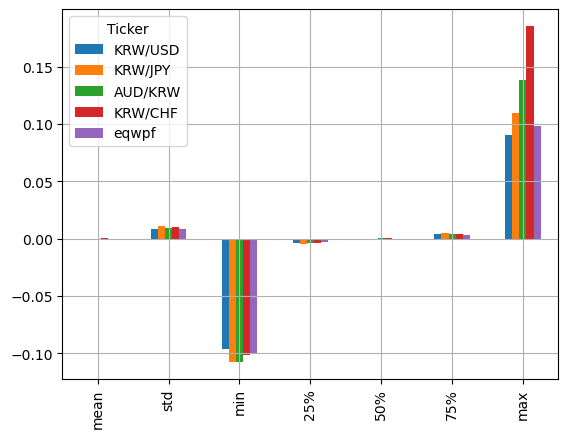

In [7]:
# compute returns
fx_krw_returns = fx_krw_prices.pct_change().iloc[1:]
fx_krw_returns['UST10Y_RFR'] = fx_krw_prices['UST10Y_RFR'] / yr_daycount
fx_krw_returns['eqwpf'] = fx_krw_returns[label_list].mean(axis=1)
# compute daily returns in excess of RFR
fx_krw_excess_returns = fx_krw_returns[invest_cols].sub(fx_krw_returns['UST10Y_RFR'], axis=0)

# add columsn: year, obs per year
fx_krw_returns['year'] = pd.to_datetime(fx_krw_returns.reset_index().Date).dt.strftime("%Y").values
fx_krw_returns['obs'] = fx_krw_returns.groupby(['year']).transform('count').mean(axis=1).values

# portfolio index
fx_krw_indices = (1+fx_krw_returns[invest_cols]).cumprod() * 100
fx_krw_rp_indices = (1+fx_krw_excess_returns[invest_cols]).cumprod() * 100

display(fx_krw_returns[invest_cols].describe())
fx_krw_returns[invest_cols].describe().iloc[1:,:].plot(kind='bar', grid=True);

### Historical Performance

count    4992.000000
mean      116.874681
std        12.920473
min        94.408654
25%       108.730914
50%       111.886479
75%       122.443659
max       162.138048
Name: eqwpf, dtype: float64

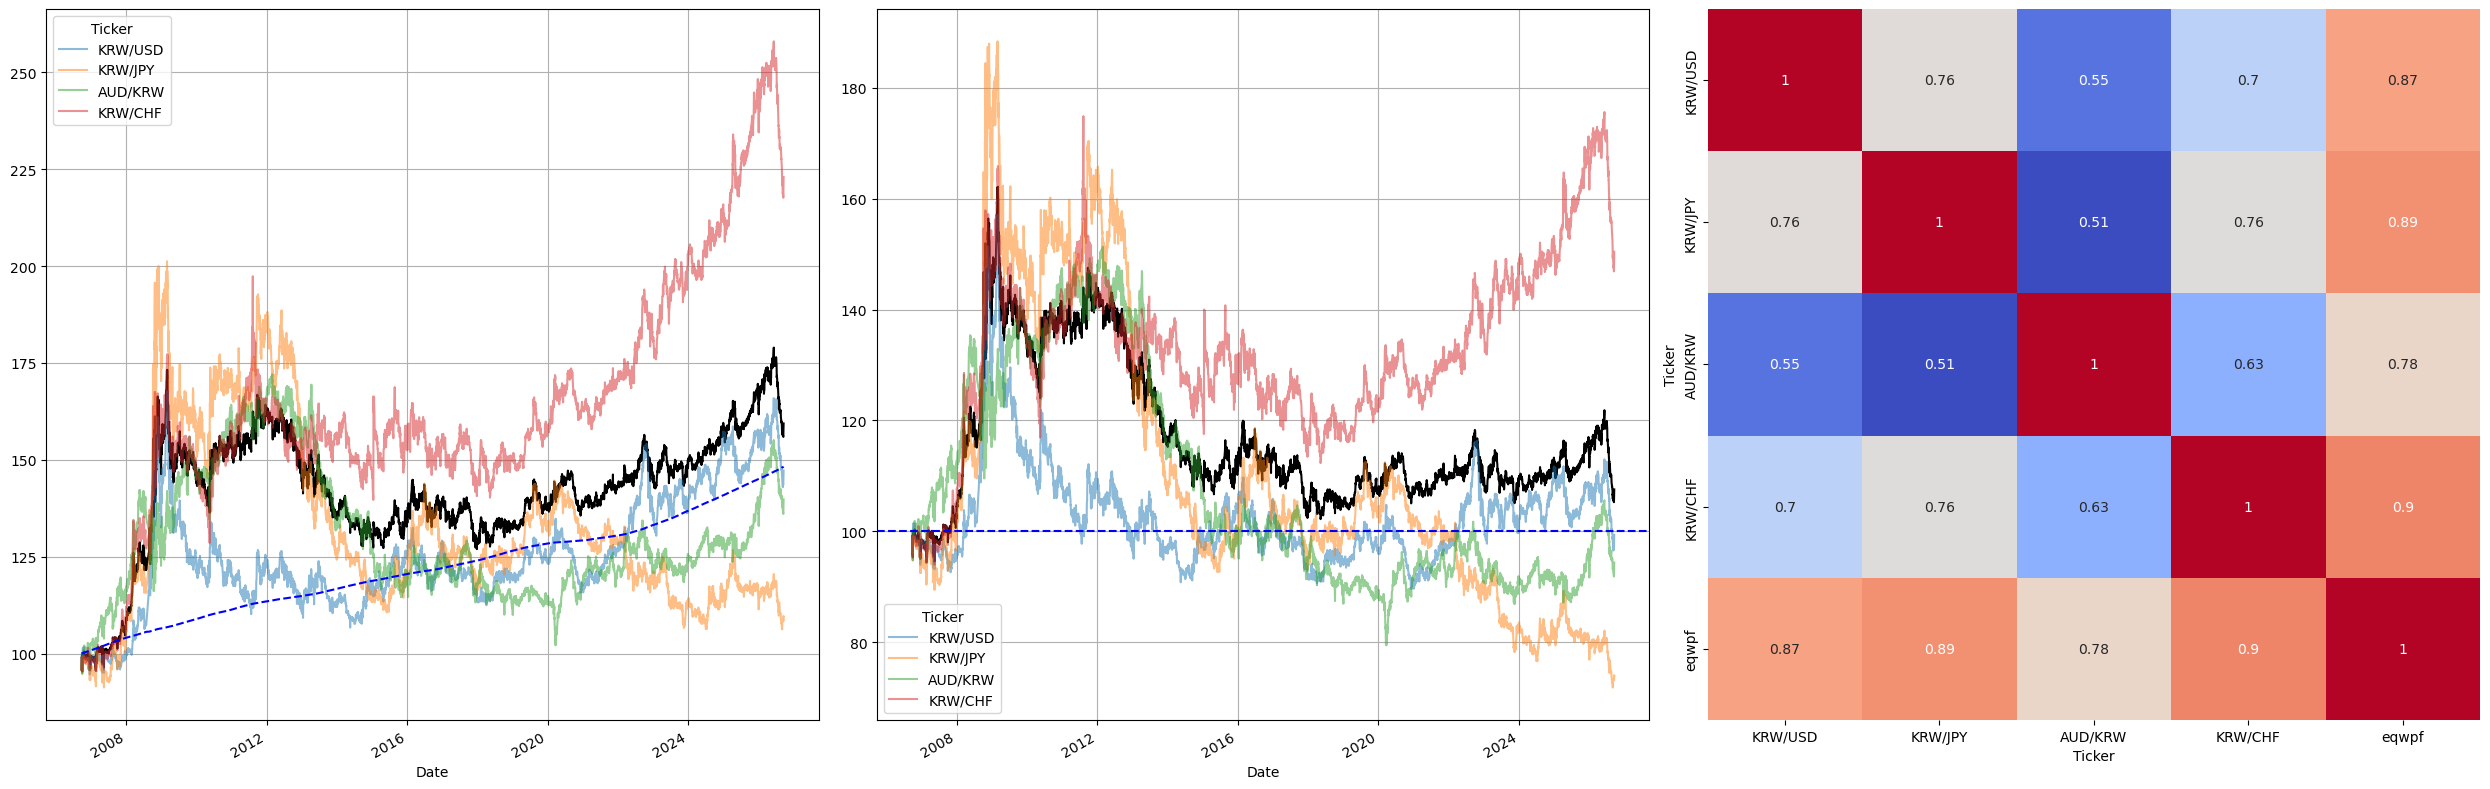

In [43]:
fig,ax = plt.subplots(1,3, figsize=(25, 8))
fx_krw_indices['eqwpf'].plot(ax=ax[0], c='black')
fx_krw_indices[label_list].plot(ax=ax[0], alpha=0.5)
((1 + (fx_krw_prices['UST10Y_RFR'] / 365)).cumprod() * 100).plot(ax=ax[0], c='blue', ls='--', label='UST10Y RFR')
ax[0].grid()

fx_krw_rp_indices['eqwpf'].plot(ax=ax[1], c='black')
fx_krw_rp_indices[label_list].plot(ax=ax[1], alpha=0.5)
ax[1].grid()
ax[1].axhline(100, c='blue', ls='--', label='UST10Y RFR')

sns.heatmap(fx_krw_returns[invest_cols].corr(), cmap='coolwarm', annot=True, cbar=False, ax=ax[2])
plt.tight_layout();

fx_krw_rp_indices['eqwpf'].describe()

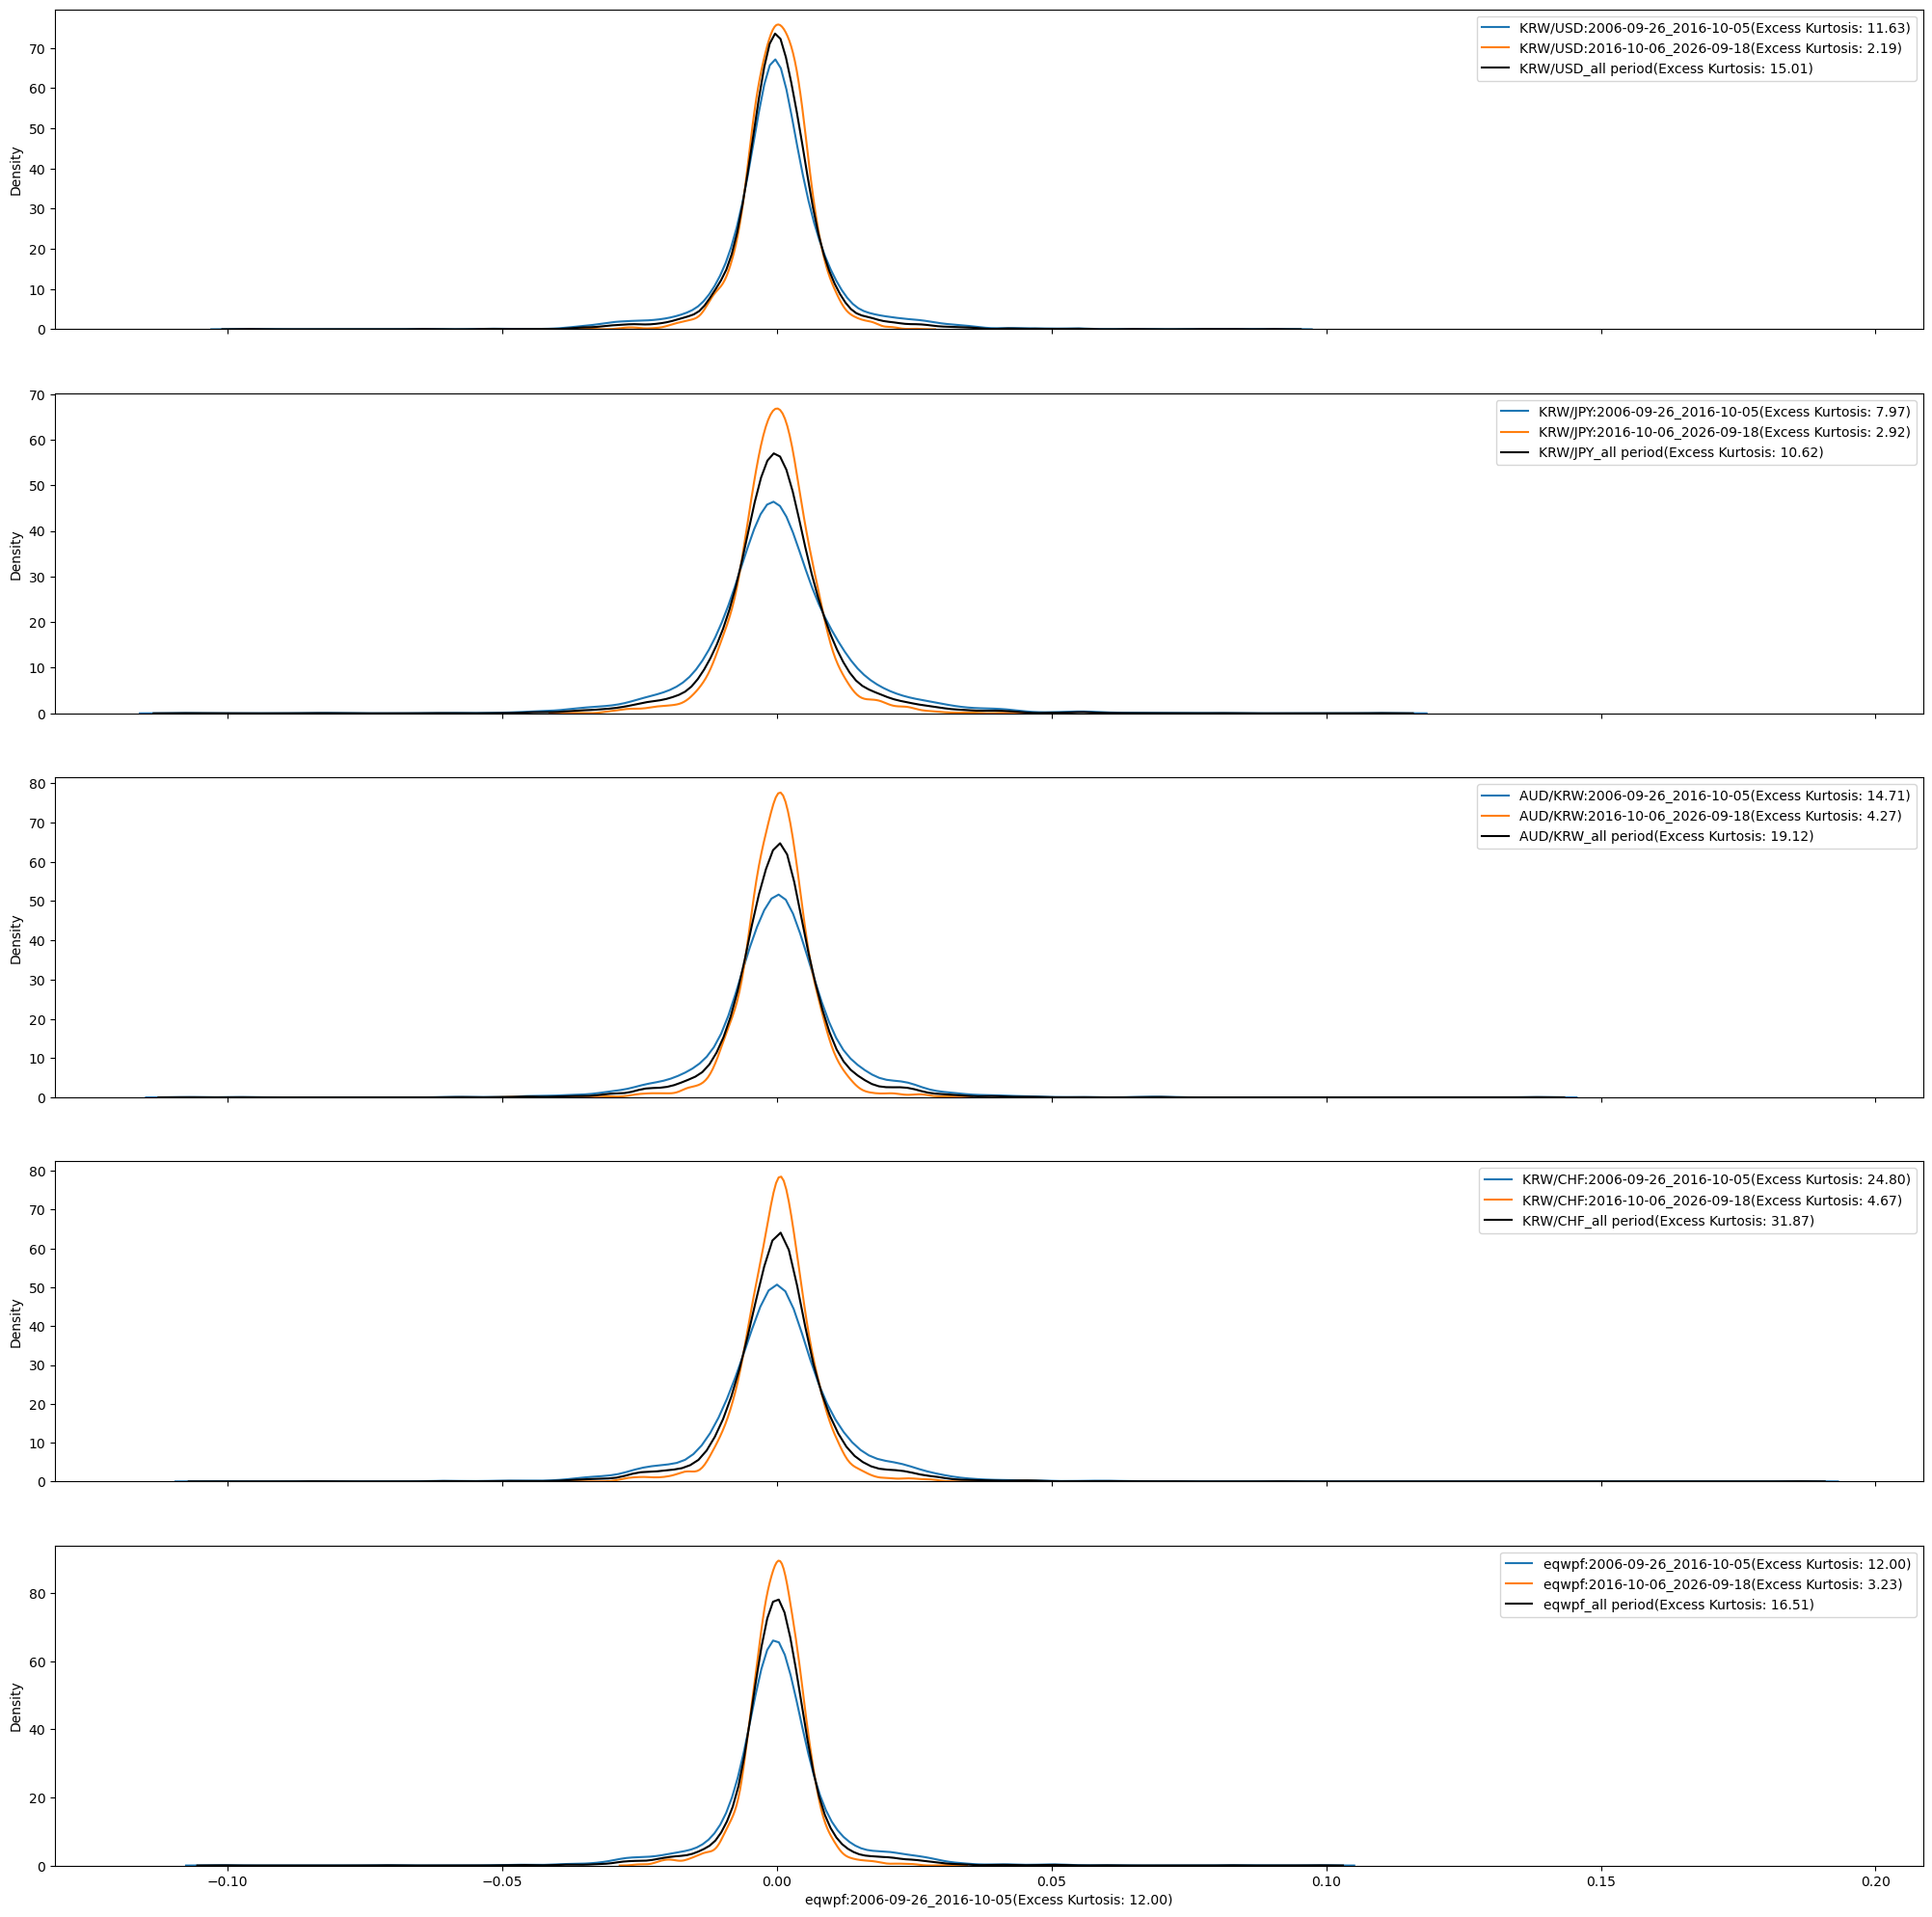

In [12]:
fig,ax = plt.subplots(len(invest_cols), 1, figsize=(25, 25), sharex=True)
#sns.histplot(fx_krw_returns[invest_cols], kde=True, alpha=0.1, stat='density', line_kws={'lw':3}, ax=ax)
for n, col in enumerate(invest_cols):
    
    n_chunks = 2
    df_chunks = np.array_split(fx_krw_returns[col], n_chunks)
    
    for i in range(n_chunks):
        s = df_chunks[i].index.min().strftime("%Y-%m-%d")
        e = df_chunks[i].index.max().strftime("%Y-%m-%d")
        df_chunks[i].name = df_chunks[i].name + ":" + str(s) + "_" + str(e) + f"(Excess Kurtosis: {df_chunks[i].kurtosis() :0.2f})"
        sns.kdeplot(df_chunks[i], ax=ax[n], label=df_chunks[i].name)
        
    sns.kdeplot(fx_krw_returns[col], ax=ax[n], 
                label=fx_krw_returns[col].name + '_all period' + f"(Excess Kurtosis: {fx_krw_returns[col].kurtosis() :0.2f})", c='black')
    
    ax[n].legend();

rolling_365d_ret:


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,4628.000000,4628.000000,4628.000000,4628.000000,4628.000000
mean,0.041723,0.030709,0.023840,0.075774,0.045181
std,0.123961,0.213864,0.108580,0.137605,0.129768
min,-0.261996,-0.320211,-0.234068,-0.228658,-0.176091
25%,-0.039434,-0.084102,-0.041930,-0.012533,-0.021037
50%,0.020235,-0.008119,0.023808,0.046854,0.025508
75%,0.087523,0.086333,0.082056,0.129789,0.074227
max,0.687120,1.097008,0.397390,0.742168,0.690746


rolling_30d_ret:


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,4963.000000,4963.000000,4963.000000,4963.000000,4963.000000
mean,0.003023,0.001635,0.002480,0.005645,0.003289
std,0.037058,0.046520,0.030861,0.035811,0.029162
min,-0.159667,-0.190593,-0.144789,-0.152905,-0.128991
25%,-0.017410,-0.022922,-0.017168,-0.016351,-0.012789
50%,0.002444,-0.003160,0.002117,0.005072,0.002886
75%,0.020361,0.019951,0.021283,0.024611,0.017394
max,0.334729,0.493737,0.171157,0.281802,0.275643


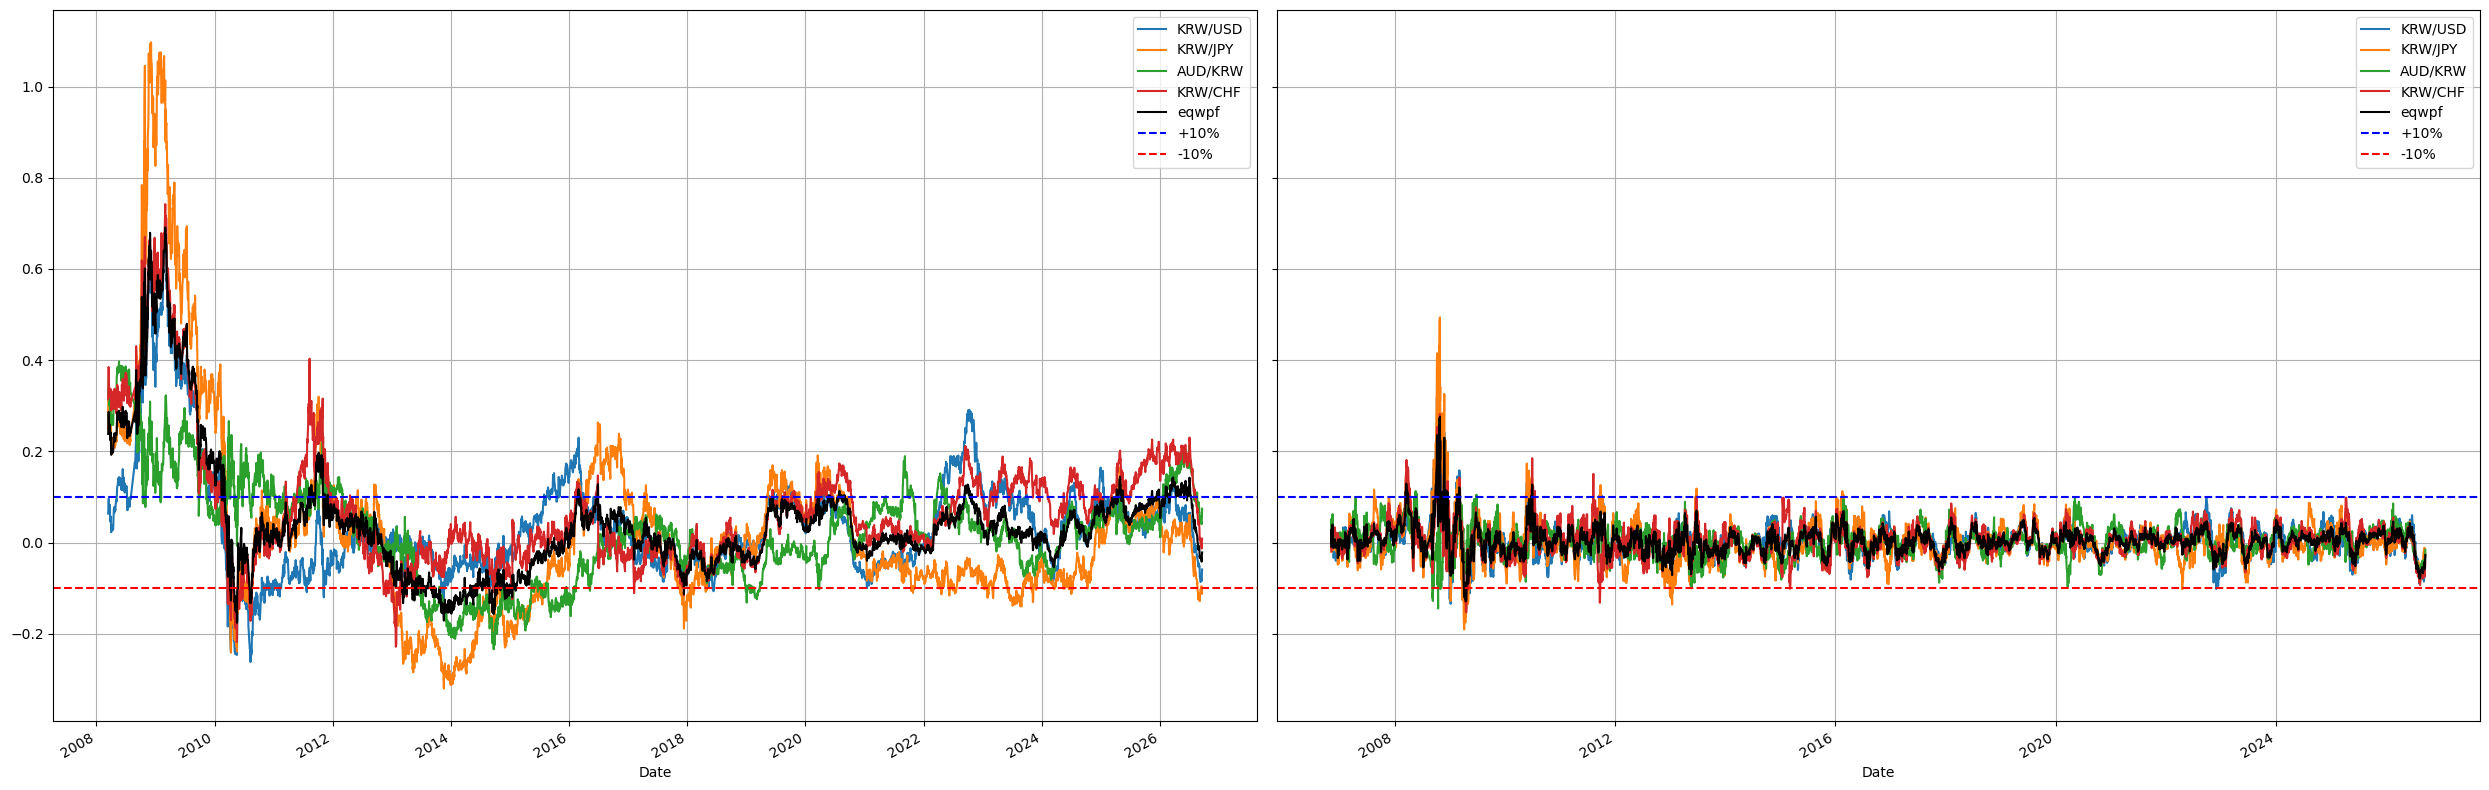

In [84]:
fig,ax = plt.subplots(1,2, figsize=(25, 8), sharey=True)

# rolling 365d returns
rolling_365d_ret = (
    (1 + fx_krw_returns[invest_cols])
    .rolling(window=yr_daycount)
    .apply(np.prod) 
    - 1
)

# rolling 30d returns annualized
rolling_30d_ret = (
    (
        (1 + fx_krw_returns[invest_cols])
        .rolling(window=30)
        .apply(np.prod)
        - 1
    ) 
)

rolling_365d_ret[label_list].plot(ax=ax[0])
rolling_30d_ret[label_list].plot(ax=ax[1])
rolling_365d_ret['eqwpf'].plot(ax=ax[0], c='black')
rolling_30d_ret['eqwpf'].plot(ax=ax[1], c='black')

for i in range(len(ax)):
    ax[i].axhline(0.10, ls='--', c='blue', label='+10%')
    ax[i].axhline(-0.10, ls='--', c='red', label='-10%')
    ax[i].grid()
    ax[i].legend()
plt.tight_layout();

print('rolling_365d_ret:')
display(rolling_365d_ret.describe())
print('rolling_30d_ret:')
display(rolling_30d_ret.describe())

rolling_365d_rp:


Ticker,KRW/USD,KRW/JPY,AUD/KRW,KRW/CHF,eqwpf
count,4628.000000,4628.000000,4628.000000,4628.000000,4628.000000
mean,0.013221,0.002153,-0.004276,0.046020,0.016385
std,0.117670,0.203785,0.101756,0.128256,0.121581
min,-0.286711,-0.333875,-0.253416,-0.243853,-0.203032
25%,-0.059067,-0.110311,-0.067179,-0.036005,-0.045654
50%,-0.007997,-0.034806,-0.004095,0.022829,-0.001085
75%,0.054760,0.057922,0.055630,0.094112,0.042581
max,0.625770,1.013073,0.337557,0.678821,0.629267


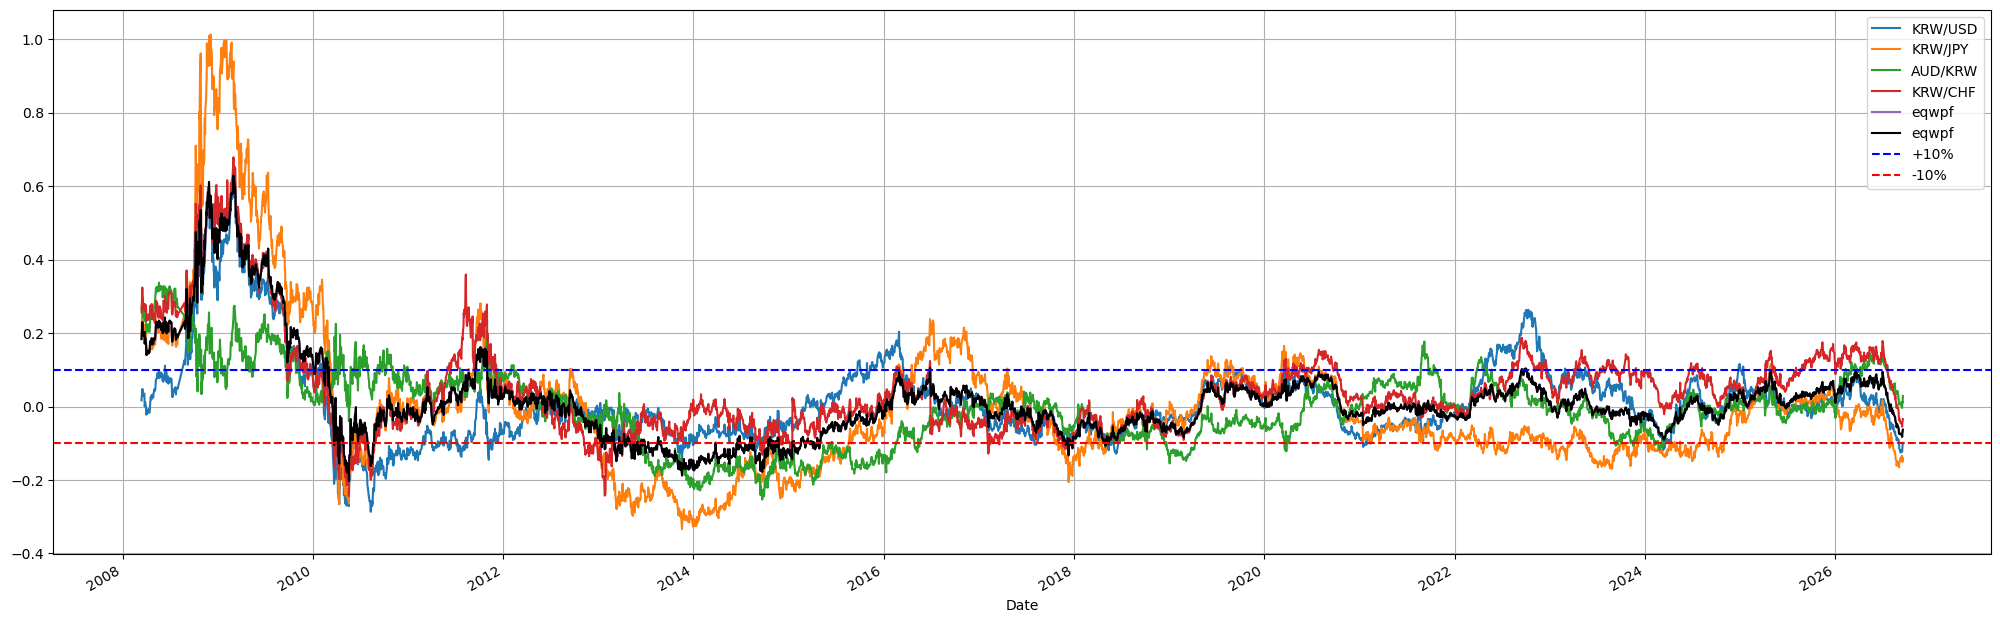

In [78]:
fig,ax = plt.subplots(figsize=(25, 8), sharey=True)

# rolling 365d risk premium
rolling_365d_rp = (
    (1 + fx_krw_excess_returns[invest_cols])
    .rolling(window=yr_daycount)
    .apply(np.prod) 
    - 1
)

rolling_365d_rp.plot(ax=ax)
rolling_365d_rp['eqwpf'].plot(ax=ax, c='black')
ax.axhline(0.10, ls='--', c='blue', label='+10%')
ax.axhline(-0.10, ls='--', c='red', label='-10%')
ax.grid()
ax.legend()

print('rolling_365d_rp:')
display(rolling_365d_rp.describe())

In [33]:
x = -0.055


percentile = (rolling_365d_ret.eqwpf.dropna() <= x).mean() * 100
# arr_sorted = np.sort(rolling_365d_ret.eqwpf.dropna())
# percentile = (np.searchsorted(arr_sorted, x, side='right') / len(arr_sorted)) * 100

print(f"PF Return of {x:.2%} is at the {percentile:.2f}th percentile of rolling_365d_ret.")


percentile = (rolling_30d_ret.eqwpf.dropna() <= x).mean() * 100
# arr_sorted = np.sort(rolling_365d_ret.eqwpf.dropna())
# percentile = (np.searchsorted(arr_sorted, x, side='right') / len(arr_sorted)) * 100

print(f"PF Return of {x:.2%} is at the {percentile:.2f}th percentile of rolling_30d_ret.")

PF Return of -5.50% is at the 15.45th percentile of rolling_365d_ret.
PF Return of -5.50% is at the 1.49th percentile of rolling_30d_ret.


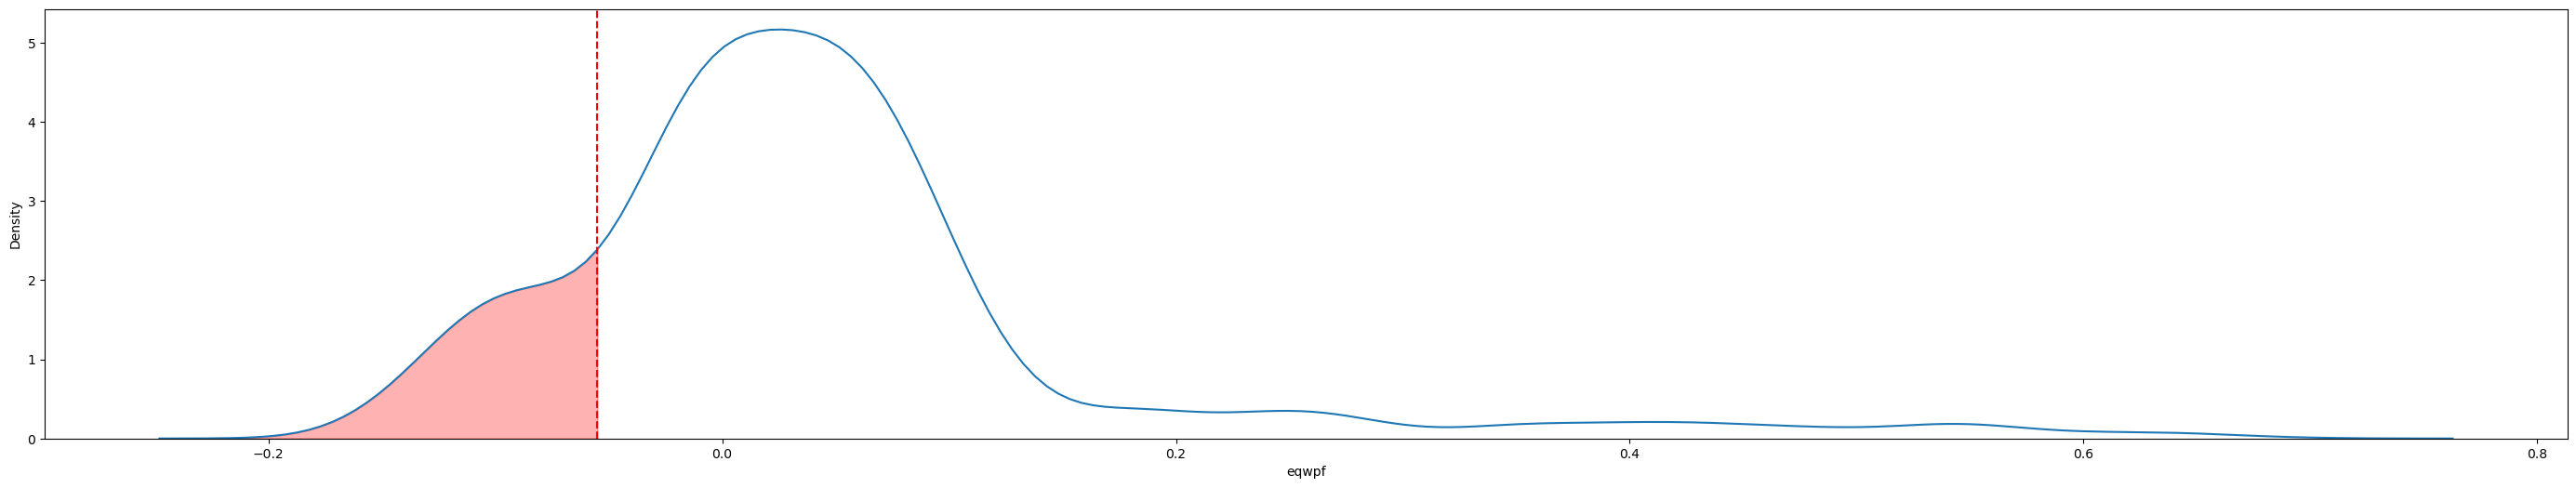

In [35]:
# fig, ax = plt.subplots(figsize=(35, 6))

# # 1. Plot KDE with Seaborn
# sns.kdeplot(rolling_365d_ret.eqwpf, ax=ax)

# # 2. Extract the line coordinates plotted for 'eqwpf'
# # (The last drawn line corresponds to 'eqwpf' as it's the last column in invest_cols)
# line = ax.lines[-1]
# x_data = line.get_xdata()
# y_data = line.get_ydata()

# # 3. Fill directly using the Seaborn curve data
# ax.fill_between(x_data, 0, y_data, where=(x_data <= x), color='red', alpha=0.3)
# ax.axvline(x, ls='--', c='red');

fig, ax = plt.subplots(figsize=(35, 6))

# 1. Plot KDE with Seaborn
sns.kdeplot(rolling_365d_ret.eqwpf, ax=ax)

# 2. Extract line coordinates
line = ax.lines[-1]
x_data = line.get_xdata()
y_data = line.get_ydata()

# 3. Interpolate y value exactly at x to close the gap
y_at_x = np.interp(x, x_data, y_data)

# Filter points strictly <= x and append the exact cutoff point (x, y_at_x)
mask = x_data <= x
x_fill = np.append(x_data[mask], x)
y_fill = np.append(y_data[mask], y_at_x)

# 4. Fill without gap
ax.fill_between(x_fill, 0, y_fill, color='red', alpha=0.3)
ax.axvline(x, ls='--', c='red');

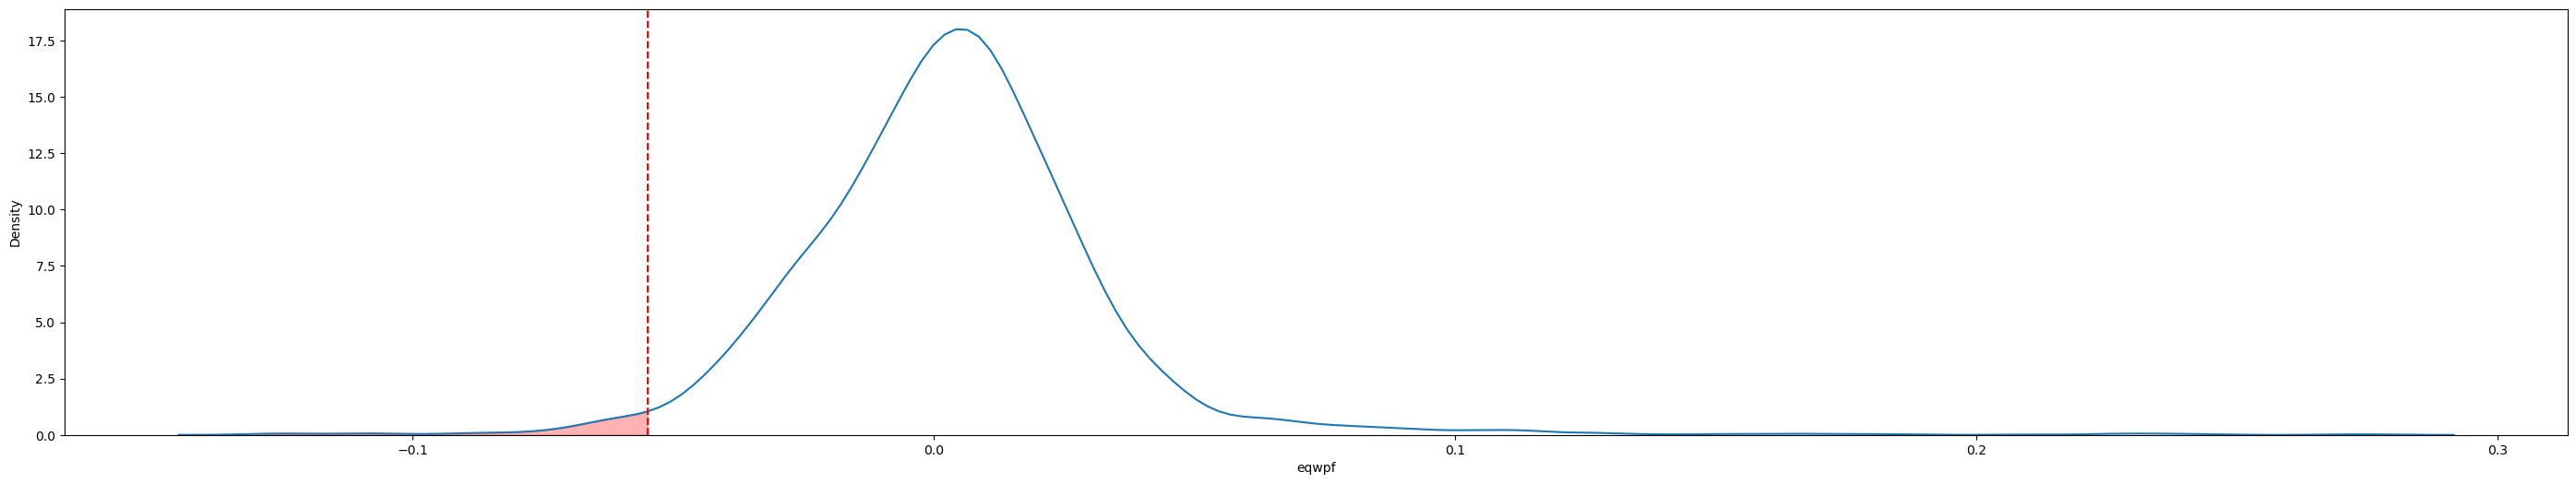

In [37]:
fig, ax = plt.subplots(figsize=(35, 6))

# 1. Plot KDE with Seaborn
sns.kdeplot(rolling_30d_ret.eqwpf, ax=ax)

# 2. Extract line coordinates
line = ax.lines[-1]
x_data = line.get_xdata()
y_data = line.get_ydata()

# 3. Interpolate y value exactly at x to close the gap
y_at_x = np.interp(x, x_data, y_data)

# Filter points strictly <= x and append the exact cutoff point (x, y_at_x)
mask = x_data <= x
x_fill = np.append(x_data[mask], x)
y_fill = np.append(y_data[mask], y_at_x)

# 4. Fill without gap
ax.fill_between(x_fill, 0, y_fill, color='red', alpha=0.3)
ax.axvline(x, ls='--', c='red');